# Estimation

This notebook estimates the job-search model

**Order of estimation**
1. L-BFGS-B: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.
2. LS-TRF: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.

For the **standard model**, `eta = 0` and `lambda = 0` are fixed. We estimate `delta`, `gamma`, the relevant search-cost parameters `k`, and the type shares `q`. `N` is fixed.

For the **reference-dependent model**, we use one type and estimate `delta`, `gamma`, `eta`, `k`, and `lambda`, while keeping `N` fixed.

This notebook produces:
- initial-fit and post-estimation hazard plots;
- estimation tables in both DataFrame and LaTeX form;
- goodness of fit (SSE);
- elapsed estimation time;
- a type-survival / survivor-composition for heterogeneous-type models.

## 1. Setup

Set `MODEL_DIR` to the folder containing `Model_components.py` if needed. The code below uses the same local path as the existing notebook by default.

In [18]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
import time

import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta


MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    "C:\\Users\\jap\\OneDrive - ROCKWOOL FONDEN\\Python Workspace\\termpaper_dynprog\\Job Search\\"
)

MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    '/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search'
)



if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

import Model_components as model

FIGURE_DIR = os.path.join(os.getcwd(), "estimation_figures")
TABLE_DIR = os.path.join(os.getcwd(), "estimation_tables")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## 2. Parameters and institutions

The computational asset grid and the initial asset distribution are separate objects. `abar` controls the state space; `weights` controls how initial asset states are represented in the simulated population.

For faster exploratory estimation, reduce `n_a` and/or `n_c`. Re-solve the final estimates on a finer grid as a robustness check.

In [19]:
# Baseline structural values / starting values
delta = 0.89
gamma = 0.81
eta_rd = 1.0
beta = 0.8

k = 359.0
k1 = 300.0
k2 = 150.0
k3 = 90.0

q1 = 0.33
q2 = 0.33

lmbda_rd = 4.9
N = 6

# Asset state space
abar = [0, 17955]

# Grid sizes
n_a = 50
n_c = 100

# Timing
T1 = 6
T2 = 18
T3 = 24
T = 44

# Pre-reform benefits
b1_pre = 222
b2_pre = 222
b3 = 114

# Post-reform benefits
b1_post = 342
b2_post = 171

welfare = 90
w = 675
R = 0.01

# 0 = heterogeneous assets; 1 = hand-to-mouth
htm = 1

institutions_pre = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_pre, b2_pre, b3, welfare, w, R
])

institutions_post = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_post, b2_post, b3, welfare, w, R
])

weights = model.make_weights(htm, abar, n_a)

target, cov = model.matchingMoments()
W = np.linalg.inv(cov)

# matchingMoments() drops the first empirical 15-day moment.
# Hence 35 retained observations correspond to days 30,...,540.
timevec = np.arange(15, 526, 15)

def split_half(arr):
    arr = np.asarray(arr)
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

emp_pre, emp_post = split_half(target)

print("Number of moments:", len(target))
print("Asset weights sum to:", weights.sum())

Number of moments: 70
Asset weights sum to: 1.0


## 3. Model specifications

The parameter vectors must match the ordering expected by `SolveMultiTypeModel`.

- Standard 1 type: `[delta, gamma, 0, k1, 0, N]`
- Standard 2 type: `[delta, gamma, 0, k1, 0, N, k2, q1]`
- Standard 3 type: `[delta, gamma, 0, k1, 0, N, k2, k3, q1, q2]`
- RD 1 type: `[delta, gamma, eta, k1, lambda, N]`

For the 3-type model, the current model defines the third share as `1 - q1 - q2`. The box bounds below keep `q1 + q2 < 1` throughout optimization.

In [20]:
def make_specs():
    specs = {}

    specs["Standard 1 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k, 0.0, N]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k],
                "lower_bound": [0.01, 1e-2, 1e-5],
                "upper_bound": [0.95, 2.0, 2000.0],
            },
            index=["delta", "gamma", "k1"]
        ),
    }

    specs["Standard 2 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k1, 0.0, N, k2, q1]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N", "k2", "q1"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k1, k2, q1],
                "lower_bound": [0.01, 1e-2, 1e-5, 1e-5, 0.01],
                "upper_bound": [0.95, 2.0, 2000.0, 2000.0, 0.99],
            },
            index=["delta", "gamma", "k1", "k2", "q1"]
        ),
    }

    specs["Standard 3 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, 0.0, k1, 0.0, N, k2, k3, q1, q2]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N", "k2", "k3", "q1", "q2"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, k1, k2, k3, q1, q2],
                "lower_bound": [0.01, 1e-2, 1e-5, 1e-5, 1e-5, 0.01, 0.01],
                # Conservative share bounds guarantee q3 = 1-q1-q2 > 0.
                # Relax using an Optimagic linear constraint if desired.
                "upper_bound": [0.95, 2.0, 2000.0, 2000.0, 2000.0, 0.49, 0.49],
            },
            index=["delta", "gamma", "k1", "k2", "k3", "q1", "q2"]
        ),
    }

    specs["Reference dependent 1 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, eta_rd, k, lmbda_rd, N]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, eta_rd, k, lmbda_rd],
                "lower_bound": [0.01, 1e-2, 0.01, 1e-5, 0.01],
                "upper_bound": [0.95, 2.0, 15.0, 2000.0, 15.0],
            },
            index=["delta", "gamma", "eta", "k1", "lmbda"]
        ),
    }

    return specs

specs = make_specs()

for name, spec in specs.items():
    print(name)
    display(spec["free"])

Standard 1 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,359.00000,0.00001,"2,000.00000"


Standard 2 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,300.00000,0.00001,"2,000.00000"
k2,150.00000,0.00001,"2,000.00000"
q1,0.33000,0.01000,0.99000


Standard 3 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
k1,300.00000,0.00001,"2,000.00000"
k2,150.00000,0.00001,"2,000.00000"
k3,90.00000,0.00001,"2,000.00000"
q1,0.33000,0.01000,0.49000
q2,0.33000,0.01000,0.49000


Reference dependent 1 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
eta,1.00000,0.01000,15.00000
k1,359.00000,0.00001,"2,000.00000"
lmbda,4.90000,0.01000,15.00000


## 4. Helper functions
These functions makes the estimation much more neat and does the following
- Create a vector of the values of the estimated parameters + those that were fixed
- Create a vector of initial values to input in the estimation
- Simulate moments (only need to input the parameters dependent on model type)
- Plot the simulated/estimated moments against the empirical moments
- Run the estimation (only need to input model name and estimation algorithm)
- Output estimation results, algorithm used, model used, SSE (goodness of fit), time it took for the estimation for a table

*** Note ***
`L-BFGS-B` uses the SSE criterion. `LS-TRF` uses the residual-vector criterion (cholesky decomposition) because it is a least-squares algorithm.



In [21]:
def full_vector_from_result(spec, result):
    full = spec["full"].copy()
    full.update(result.params)
    return full["value"].to_numpy()


def initial_vector(spec):
    return spec["full"]["value"].to_numpy().copy()


def simulate_fit(params_vec):
    moments = model.simulate_moments(
        params_vec,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )
    return split_half(moments)


def plot_fit(params_vec, title, filename=None):
    pred_pre, pred_post = simulate_fit(params_vec)

    

    plt.plot(timevec, emp_pre, marker=".", label="Empirical pre-reform",  color='tab:blue')
    plt.plot(timevec, emp_post, marker=".", label="Empirical post-reform",  color='tab:red')
    plt.plot(timevec, pred_pre, linestyle="--", label="Model pre-reform", color='tab:blue')
    plt.plot(timevec, pred_post, linestyle="--", label="Model post-reform", color='tab:red')

    plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.1, colors='black', linestyles='dashed')

    plt.xlabel("Number of days since UI claim")
    plt.ylabel("Hazard rate")
    plt.title(title)
    plt.xlim(0, 560)
    plt.ylim(0, 0.1)
    plt.xticks(np.arange(0, 541, 90))
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    

    if filename is not None:
        plt.savefig(os.path.join(FIGURE_DIR, filename), bbox_inches="tight")

    plt.show()
    


def run_estimation(model_name, algorithm):
    spec = specs[model_name]

    smm_object = model.smm(
        spec["full"].copy(),
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    if algorithm == "scipy_lbfgsb":
        criterion = smm_object.sse
    elif algorithm == "scipy_ls_trf":
        criterion = smm_object.criterion
    else:
        raise ValueError("Unsupported algorithm.")

    start = time.perf_counter()

    result = om.minimize(
        criterion=criterion,
        params=spec["free"].copy(),
        algorithm=algorithm,
    )

    elapsed = time.perf_counter() - start

    params_hat = full_vector_from_result(spec, result)

    # Compute the same quadratic SSE for all algorithms for direct comparison.
    sse_hat = model.sse(
        params_hat,
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    return {
        "model": model_name,
        "algorithm": algorithm,
        "result": result,
        "params_hat": params_hat,
        "sse": float(sse_hat),
        "seconds": elapsed,
        "full_index": list(spec["full"].index),
    }


def result_row(out):
    values = dict(zip(out["full_index"], out["params_hat"]))
    return {
        "Algorithm": out["algorithm"],
        "Model": out["model"],
        "delta": values.get("delta", np.nan),
        "gamma": values.get("gamma", np.nan),
        "eta": values.get("eta", np.nan),
        "lambda": values.get("lmbda", np.nan),
        "k1": values.get("k1", np.nan),
        "k2": values.get("k2", np.nan),
        "k3": values.get("k3", np.nan),
        "q1": values.get("q1", np.nan),
        "q2": values.get("q2", np.nan),
        "q3": (
            1 - values.get("q1", 0) - values.get("q2", 0)
            if "q2" in values else
            (1 - values.get("q1", 0) if "q1" in values else np.nan)
        ),
        "SSE": out["sse"],
        "Minutes": out["seconds"] / 60,
    }


results = {}

# 5. L-BFGS-B

Each subsection first plots the fit at the starting values, then estimates the model, and finally plots the fitted hazards at the estimated parameters.

## 5.1 Standard 1-type

In [22]:
plot_fit(
    initial_vector(specs['Standard 1 type']),
    'Initial fit — Standard 1 type (L-BFGS-B)',
    'lbfgsb_st1_before.pdf',
)

TypeError: SolveForward() missing 1 required positional argument: 'htm'

In [7]:
results[("L-BFGS-B", 'Standard 1 type')] = run_estimation(
    'Standard 1 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


KeyboardInterrupt: 

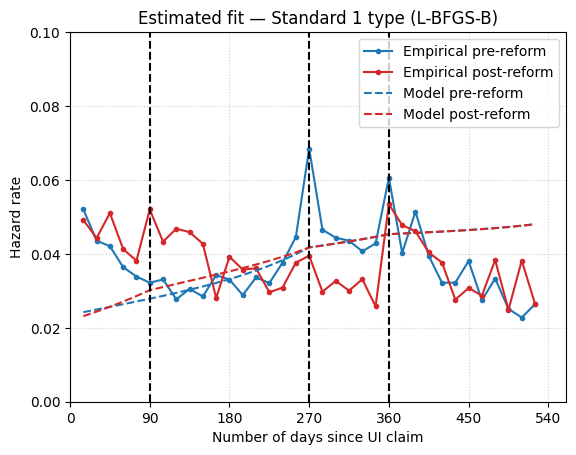

In [92]:
plot_fit(
    results[("L-BFGS-B", 'Standard 1 type')]["params_hat"],
    'Estimated fit — Standard 1 type (L-BFGS-B)',
    'lbfgsb_st1_after.pdf',
)

## 5.2 Standard 2-type

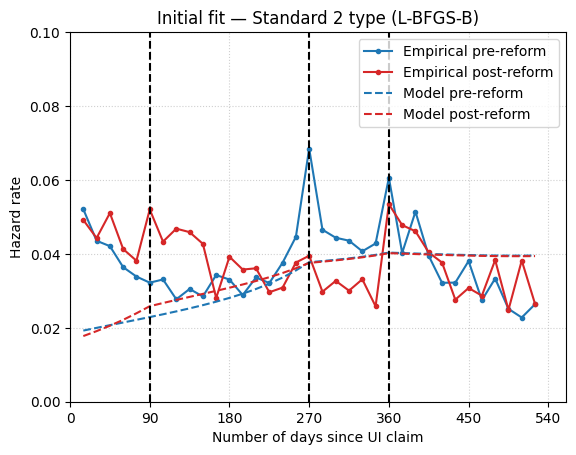

In [93]:
plot_fit(
    initial_vector(specs['Standard 2 type']),
    'Initial fit — Standard 2 type (L-BFGS-B)',
    'lbfgsb_st2_before.pdf',
)

In [ ]:
results[("L-BFGS-B", 'Standard 2 type')] = run_estimation(
    'Standard 2 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 2 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


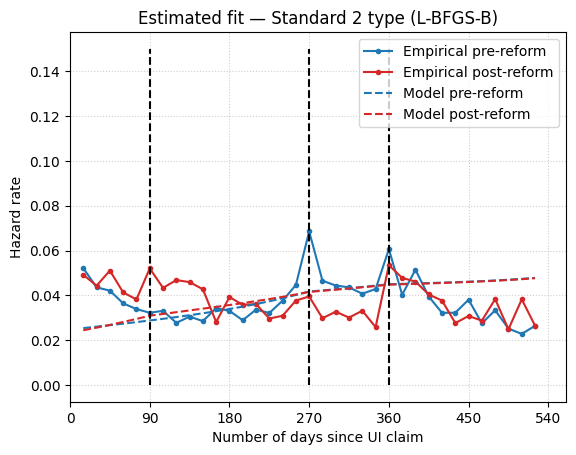

In [ ]:
plot_fit(
    results[("L-BFGS-B", 'Standard 2 type')]["params_hat"],
    'Estimated fit — Standard 2 type (L-BFGS-B)',
    'lbfgsb_st2_after.pdf',
)

## 5.3 Standard 3-type

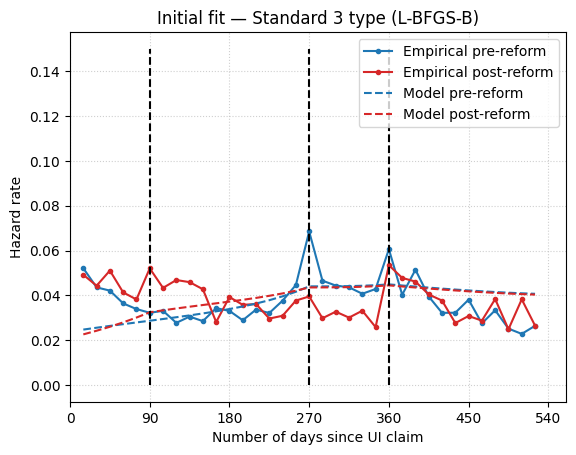

In [ ]:
plot_fit(
    initial_vector(specs['Standard 3 type']),
    'Initial fit — Standard 3 type (L-BFGS-B)',
    'lbfgsb_st3_before.pdf',
)

In [ ]:
results[("L-BFGS-B", 'Standard 3 type')] = run_estimation(
    'Standard 3 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Standard 3 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Estimated parameters: [9.03269619e-01 7.95118463e-01 0.00000000e+00 3.97626953e+02
 0.00000000e+00 6.00000000e+00 1.38627734e+02 1.82585105e+01
 3.51556658e-01 4.24856733e-01]
SSE: 95.521585
Elapsed: 109.38 minutes


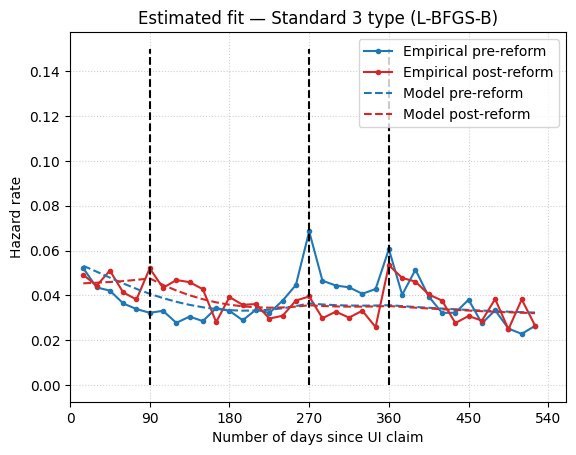

In [ ]:
plot_fit(
    results[("L-BFGS-B", 'Standard 3 type')]["params_hat"],
    'Estimated fit — Standard 3 type (L-BFGS-B)',
    'lbfgsb_st3_after.pdf',
)

## 5.4 Reference dependent 1 type

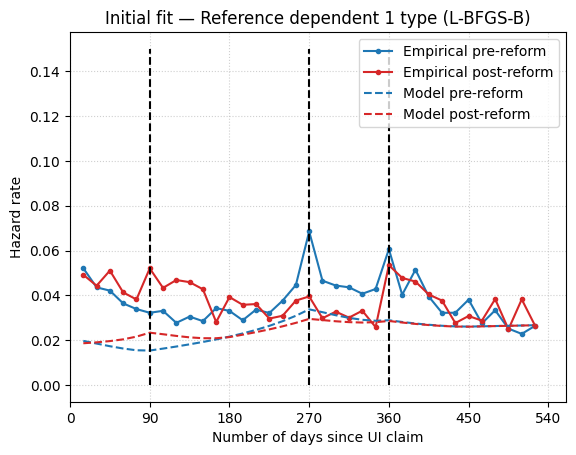

In [ ]:
plot_fit(
    initial_vector(specs['Reference dependent 1 type']),
    'Initial fit — Reference dependent 1 type (L-BFGS-B)',
    'lbfgsb_rd1_before.pdf',
)

In [ ]:
results[("L-BFGS-B", 'Reference dependent 1 type')] = run_estimation(
    'Reference dependent 1 type',
    "scipy_lbfgsb"
)

out = results[("L-BFGS-B", 'Reference dependent 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Estimated parameters: [  0.95         0.66311239   1.07306839 358.51466885  13.8702157
   6.        ]
SSE: 133.367606
Elapsed: 31.15 minutes


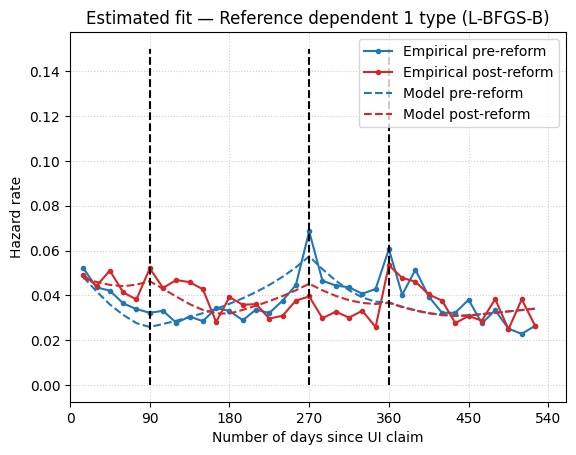

In [ ]:
plot_fit(
    results[("L-BFGS-B", 'Reference dependent 1 type')]["params_hat"],
    'Estimated fit — Reference dependent 1 type (L-BFGS-B)',
    'lbfgsb_rd1_after.pdf',
)

## 5.5 Estimation Table 1 (L-BFGS-B)

The LaTeX table is printed in the notebook and also saved to `estimation_tables/lbfgsb_results.tex`.

In [ ]:
lbfgsb_table = pd.DataFrame([
    result_row(results[("L-BFGS-B", name)])
    for name in specs.keys()
])

display(lbfgsb_table)

lbfgsb_latex = lbfgsb_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using L-BFGS-B.",
    label="tab:lbfgsb_estimates",
)

print(lbfgsb_latex)

with open(os.path.join(TABLE_DIR, "lbfgsb_results.tex"), "w", encoding="utf-8") as f:
    f.write(lbfgsb_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
0,scipy_lbfgsb,Standard 1 type,0.91381,0.97702,0.00000,0.00000,358.19481,NaN,NaN,NaN,NaN,NaN,559.74142,11.72907
1,scipy_lbfgsb,Standard 2 type,0.94221,0.72519,0.00000,0.00000,300.03636,150.52343,NaN,0.60479,NaN,0.39521,517.72982,51.26212
2,scipy_lbfgsb,Standard 3 type,0.90327,0.79512,0.00000,0.00000,397.62695,138.62773,18.25851,0.35156,0.42486,0.22359,95.52158,109.38387
3,scipy_lbfgsb,Reference dependent 1 type,0.95000,0.66311,1.07307,13.87022,358.51467,NaN,NaN,NaN,NaN,NaN,133.36761,31.15202


\begin{table}
\caption{SMM estimates using L-BFGS-B.}
\label{tab:lbfgsb_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_lbfgsb & Standard 1 type & 0.9138 & 0.9770 & 0.0000 & 0.0000 & 358.1948 & -- & -- & -- & -- & -- & 559.7414 & 11.7291 \\
scipy_lbfgsb & Standard 2 type & 0.9422 & 0.7252 & 0.0000 & 0.0000 & 300.0364 & 150.5234 & -- & 0.6048 & -- & 0.3952 & 517.7298 & 51.2621 \\
scipy_lbfgsb & Standard 3 type & 0.9033 & 0.7951 & 0.0000 & 0.0000 & 397.6270 & 138.6277 & 18.2585 & 0.3516 & 0.4249 & 0.2236 & 95.5216 & 109.3839 \\
scipy_lbfgsb & Reference dependent 1 type & 0.9500 & 0.6631 & 1.0731 & 13.8702 & 358.5147 & -- & -- & -- & -- & -- & 133.3676 & 31.1520 \\
\bottomrule
\end{tabular}
\end{table}



# 6. LS-TRF

LS-TRF uses `smm_object.criterion`, which returns root contributions for the least-squares solver. The reported SSE is recomputed using the same quadratic criterion as for L-BFGS-B.

## 6.1 Standard 1-type

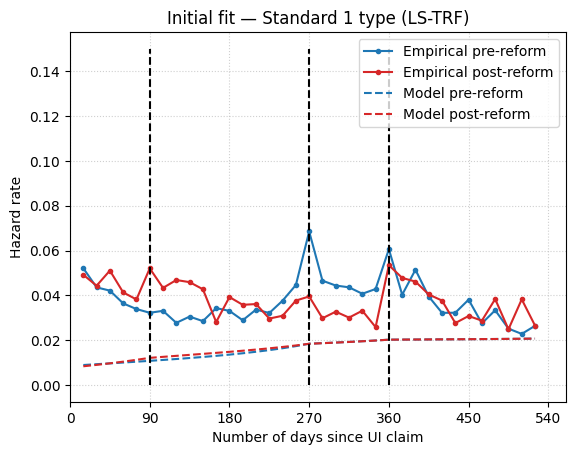

In [ ]:
plot_fit(
    initial_vector(specs['Standard 1 type']),
    'Initial fit — Standard 1 type (LS-TRF)',
    'lstrf_st1_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Standard 1 type')] = run_estimation(
    'Standard 1 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [  0.91675751   0.92671543   0.         315.82580651   0.
   6.        ]
SSE: 578.557492
Elapsed: 1.97 minutes


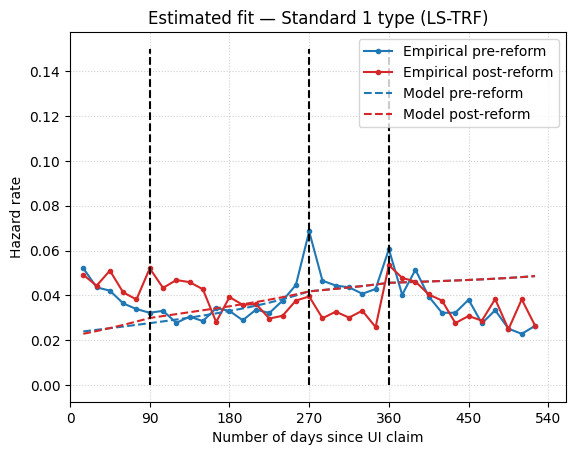

In [ ]:
plot_fit(
    results[("LS-TRF", 'Standard 1 type')]["params_hat"],
    'Estimated fit — Standard 1 type (LS-TRF)',
    'lstrf_st1_after.pdf',
)

## 6.2 Standard 2-type

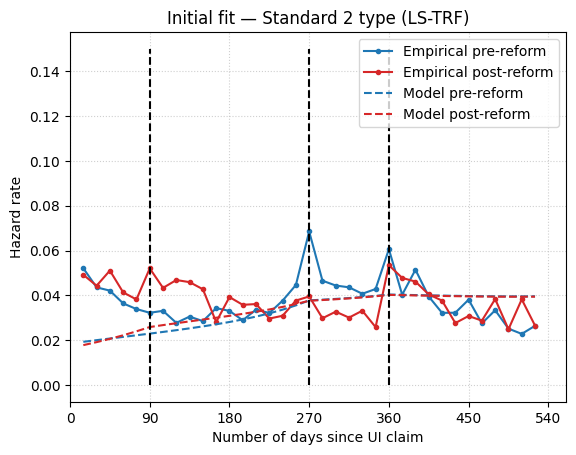

In [ ]:
plot_fit(
    initial_vector(specs['Standard 2 type']),
    'Initial fit — Standard 2 type (LS-TRF)',
    'lstrf_st2_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Standard 2 type')] = run_estimation(
    'Standard 2 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 2 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [8.27847552e-01 1.36317620e+00 0.00000000e+00 8.99937867e+02
 0.00000000e+00 6.00000000e+00 3.59179039e+01 7.51095163e-01]
SSE: 96.626462
Elapsed: 12.06 minutes


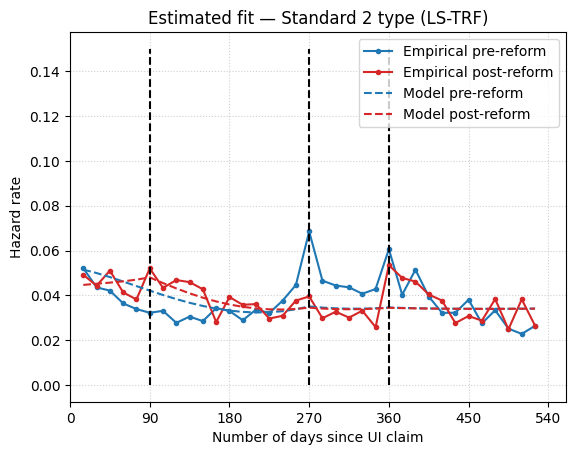

In [ ]:
plot_fit(
    results[("LS-TRF", 'Standard 2 type')]["params_hat"],
    'Estimated fit — Standard 2 type (LS-TRF)',
    'lstrf_st2_after.pdf',
)

## 6.3 Standard 3-type

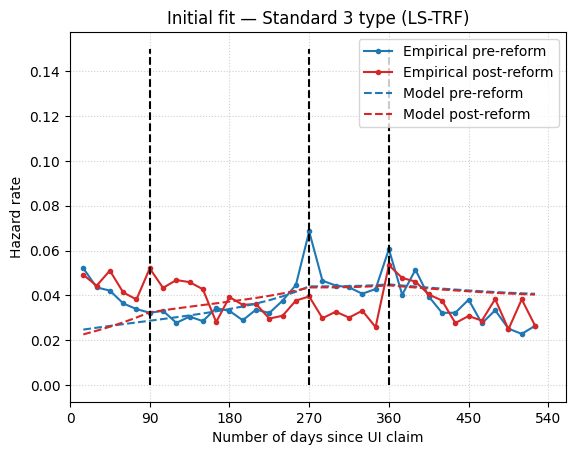

In [ ]:
plot_fit(
    initial_vector(specs['Standard 3 type']),
    'Initial fit — Standard 3 type (LS-TRF)',
    'lstrf_st3_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Standard 3 type')] = run_estimation(
    'Standard 3 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Standard 3 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [7.76798039e-01 1.28588022e+00 0.00000000e+00 7.30853708e+02
 0.00000000e+00 6.00000000e+00 2.00339193e+02 1.66959870e+01
 4.89892204e-01 3.19660328e-01]
SSE: 94.688959
Elapsed: 9.36 minutes


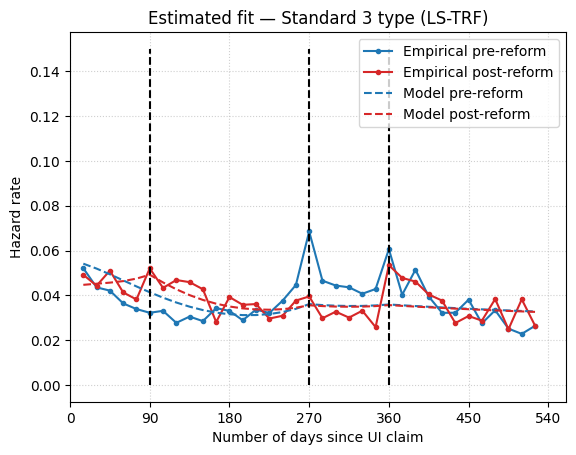

In [ ]:
plot_fit(
    results[("LS-TRF", 'Standard 3 type')]["params_hat"],
    'Estimated fit — Standard 3 type (LS-TRF)',
    'lstrf_st3_after.pdf',
)

## 6.4 Reference dependent 1 type

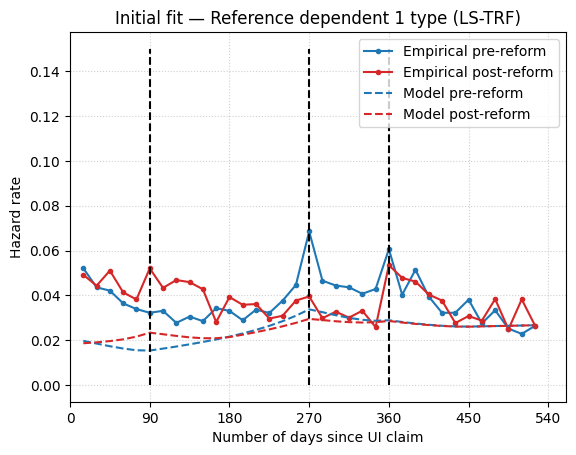

In [ ]:
plot_fit(
    initial_vector(specs['Reference dependent 1 type']),
    'Initial fit — Reference dependent 1 type (LS-TRF)',
    'lstrf_rd1_before.pdf',
)

In [ ]:
results[("LS-TRF", 'Reference dependent 1 type')] = run_estimation(
    'Reference dependent 1 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Reference dependent 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
c:\Users\jap\AppData\Local\miniconda3\Lib\site-packages\optimagic\deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.w

Estimated parameters: [  0.94999115   0.92545269   1.38424803 894.3129225   14.99342322
   6.        ]
SSE: 126.520887
Elapsed: 3.18 minutes


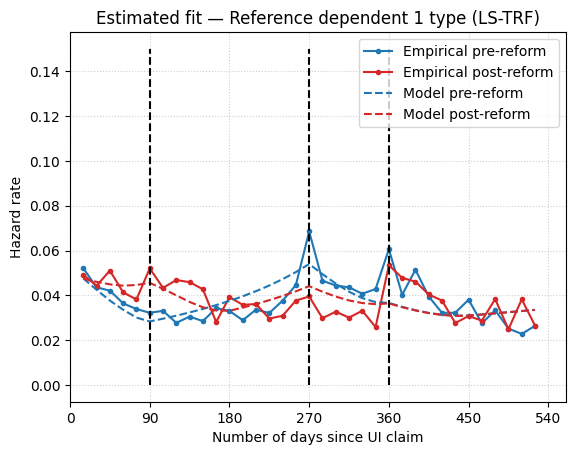

In [ ]:
plot_fit(
    results[("LS-TRF", 'Reference dependent 1 type')]["params_hat"],
    'Estimated fit — Reference dependent 1 type (LS-TRF)',
    'lstrf_rd1_after.pdf',
)

## 6.5 Estimation Table 2 (LS-TRF)

In [ ]:
lstrf_table = pd.DataFrame([
    result_row(results[("LS-TRF", name)])
    for name in specs.keys()
])

display(lstrf_table)

lstrf_latex = lstrf_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using LS-TRF.",
    label="tab:lstrf_estimates",
)

print(lstrf_latex)

with open(os.path.join(TABLE_DIR, "lstrf_results.tex"), "w", encoding="utf-8") as f:
    f.write(lstrf_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
0,scipy_ls_trf,Standard 1 type,0.91676,0.92672,0.00000,0.00000,315.82581,NaN,NaN,NaN,NaN,NaN,578.55749,1.97433
1,scipy_ls_trf,Standard 2 type,0.82785,1.36318,0.00000,0.00000,899.93787,35.91790,NaN,0.75110,NaN,0.24890,96.62646,12.06254
2,scipy_ls_trf,Standard 3 type,0.77680,1.28588,0.00000,0.00000,730.85371,200.33919,16.69599,0.48989,0.31966,0.19045,94.68896,9.35979
3,scipy_ls_trf,Reference dependent 1 type,0.94999,0.92545,1.38425,14.99342,894.31292,NaN,NaN,NaN,NaN,NaN,126.52089,3.17977


\begin{table}
\caption{SMM estimates using LS-TRF.}
\label{tab:lstrf_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_ls_trf & Standard 1 type & 0.9168 & 0.9267 & 0.0000 & 0.0000 & 315.8258 & -- & -- & -- & -- & -- & 578.5575 & 1.9743 \\
scipy_ls_trf & Standard 2 type & 0.8278 & 1.3632 & 0.0000 & 0.0000 & 899.9379 & 35.9179 & -- & 0.7511 & -- & 0.2489 & 96.6265 & 12.0625 \\
scipy_ls_trf & Standard 3 type & 0.7768 & 1.2859 & 0.0000 & 0.0000 & 730.8537 & 200.3392 & 16.6960 & 0.4899 & 0.3197 & 0.1904 & 94.6890 & 9.3598 \\
scipy_ls_trf & Reference dependent 1 type & 0.9500 & 0.9255 & 1.3842 & 14.9934 & 894.3129 & -- & -- & -- & -- & -- & 126.5209 & 3.1798 \\
\bottomrule
\end{tabular}
\end{table}



# 7. Estimator comparison

This table puts the two optimizers side by side for a comparison of parameter stability, goodness of fit, and runtime.

In [ ]:
combined_table = pd.concat(
    [lbfgsb_table, lstrf_table],
    ignore_index=True
).sort_values(["Model", "Algorithm"])

display(combined_table)

combined_latex = combined_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates across model specifications and optimization algorithms.",
    label="tab:all_estimates",
)

print(combined_latex)

with open(os.path.join(TABLE_DIR, "all_estimates.tex"), "w", encoding="utf-8") as f:
    f.write(combined_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
3,scipy_lbfgsb,Reference dependent 1 type,0.95000,0.66311,1.07307,13.87022,358.51467,NaN,NaN,NaN,NaN,NaN,133.36761,31.15202
7,scipy_ls_trf,Reference dependent 1 type,0.94999,0.92545,1.38425,14.99342,894.31292,NaN,NaN,NaN,NaN,NaN,126.52089,3.17977
0,scipy_lbfgsb,Standard 1 type,0.91381,0.97702,0.00000,0.00000,358.19481,NaN,NaN,NaN,NaN,NaN,559.74142,11.72907
4,scipy_ls_trf,Standard 1 type,0.91676,0.92672,0.00000,0.00000,315.82581,NaN,NaN,NaN,NaN,NaN,578.55749,1.97433
1,scipy_lbfgsb,Standard 2 type,0.94221,0.72519,0.00000,0.00000,300.03636,150.52343,NaN,0.60479,NaN,0.39521,517.72982,51.26212
5,scipy_ls_trf,Standard 2 type,0.82785,1.36318,0.00000,0.00000,899.93787,35.91790,NaN,0.75110,NaN,0.24890,96.62646,12.06254
2,scipy_lbfgsb,Standard 3 type,0.90327,0.79512,0.00000,0.00000,397.62695,138.62773,18.25851,0.35156,0.42486,0.22359,95.52158,109.38387
6,scipy_ls_trf,Standard 3 type,0.77680,1.28588,0.00000,0.00000,730.85371,200.33919,16.69599,0.48989,0.31966,0.19045,94.68896,9.35979


\begin{table}
\caption{SMM estimates across model specifications and optimization algorithms.}
\label{tab:all_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_lbfgsb & Reference dependent 1 type & 0.9500 & 0.6631 & 1.0731 & 13.8702 & 358.5147 & -- & -- & -- & -- & -- & 133.3676 & 31.1520 \\
scipy_ls_trf & Reference dependent 1 type & 0.9500 & 0.9255 & 1.3842 & 14.9934 & 894.3129 & -- & -- & -- & -- & -- & 126.5209 & 3.1798 \\
scipy_lbfgsb & Standard 1 type & 0.9138 & 0.9770 & 0.0000 & 0.0000 & 358.1948 & -- & -- & -- & -- & -- & 559.7414 & 11.7291 \\
scipy_ls_trf & Standard 1 type & 0.9168 & 0.9267 & 0.0000 & 0.0000 & 315.8258 & -- & -- & -- & -- & -- & 578.5575 & 1.9743 \\
scipy_lbfgsb & Standard 2 type & 0.9422 & 0.7252 & 0.0000 & 0.0000 & 300.0364 & 150.5234 & -- & 0.6048 & -- & 0.3952 & 517.7298 & 51.2621 \\
scipy_ls_trf & Standard 2 type & 0.8278 & 1.3632 & 0.0000 & 

# 8. Heterogeneity mechanism: survival and dilution of low-​`k` types

A heterogeneous-type model can generate a declining aggregate hazard even when each type's own hazard is not declining as much. Low-`k` types search more intensely, exit unemployment earlier, and therefore make up a progressively smaller share of the unemployment pool.

The cells below use the estimated **L-BFGS-B 3-type standard model**. Change `mechanism_key` to the 2-type model or LS-TRF if desired.

In [ ]:
def unpack_type_structure(params_vec):
    p = np.asarray(params_vec).ravel()

    if len(p) == 6:
        delta_, gamma_, eta_, k1_, lmbda_, N_ = p
        return [k1_], np.array([1.0]), [delta_, gamma_, eta_, lmbda_, N_]

    if len(p) == 8:
        delta_, gamma_, eta_, k1_, lmbda_, N_, k2_, q1_ = p
        return [k1_, k2_], np.array([q1_, 1-q1_]), [delta_, gamma_, eta_, lmbda_, N_]

    if len(p) == 10:
        delta_, gamma_, eta_, k1_, lmbda_, N_, k2_, k3_, q1_, q2_ = p
        return [k1_, k2_, k3_], np.array([q1_, q2_, 1-q1_-q2_]), [delta_, gamma_, eta_, lmbda_, N_]

    raise ValueError("Unsupported parameter vector length.")


def type_survival_diagnostics(params_vec, institutions):
    kvals, shares, common = unpack_type_structure(params_vec)
    delta_, gamma_, eta_, lmbda_, N_ = common

    pop_survivals = []

    for k_j in kvals:
        params_j = np.array([delta_, gamma_, eta_, k_j, lmbda_, N_])
        _, _, survival_j, _, _, _ = model.SolveForward(
            params_j, institutions, abar, htm
        )

        # Integrate over the initial asset distribution within each type.
        pop_survivals.append(weights @ survival_j)

    pop_survivals = np.asarray(pop_survivals)

    survivor_mass = shares[:, None] * pop_survivals
    survivor_composition = survivor_mass / survivor_mass.sum(axis=0, keepdims=True)

    return np.asarray(kvals), shares, pop_survivals, survivor_composition


mechanism_key = ("L-BFGS-B", "Standard 3 type")
params_mech = results[mechanism_key]["params_hat"]

kvals_mech, shares_mech, survival_mech, composition_mech =     type_survival_diagnostics(params_mech, institutions_pre)

timevec_survival = np.arange(T + 1) * 15

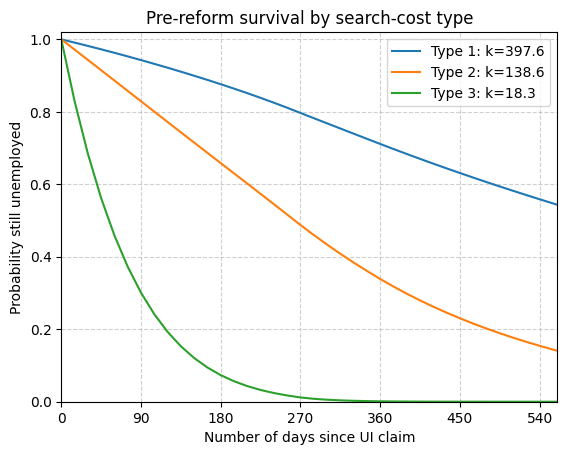

In [ ]:
# Type-specific survival probabilities


for j, k_j in enumerate(kvals_mech):
    plt.plot(
        timevec_survival,
        survival_mech[j],
        label=f"Type {j+1}: k={k_j:.1f}"
    )

plt.xlabel("Number of days since UI claim")
plt.ylabel("Probability still unemployed")
plt.title("Pre-reform survival by search-cost type")
plt.xlim(0, 560)
plt.xticks(np.arange(0, 561, 90))
plt.ylim(0, 1.02)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(os.path.join(FIGURE_DIR, "type_survival_pre.pdf"), bbox_inches="tight")
plt.show()

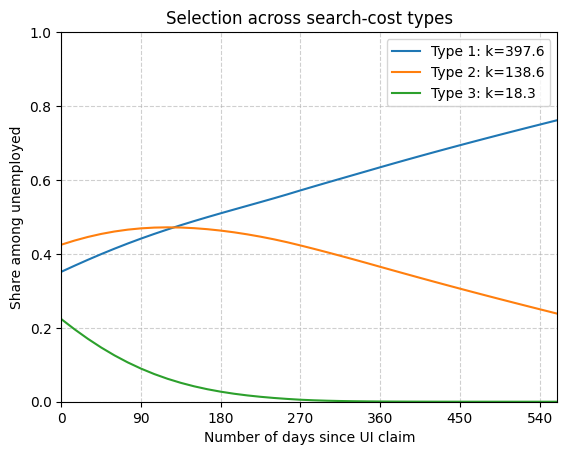

In [ ]:
# Composition of the remaining unemployment pool

for j, k_j in enumerate(kvals_mech):
    plt.plot(
        timevec_survival,
        composition_mech[j],
        label=f"Type {j+1}: k={k_j:.1f}"
    )

plt.xlabel("Number of days since UI claim")
plt.ylabel("Share among unemployed")
plt.title("Selection across search-cost types")
plt.xlim(0, 560)
plt.xticks(np.arange(0, 561, 90))
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(os.path.join(FIGURE_DIR, "type_composition_pre.pdf"), bbox_inches="tight")
plt.show()

# Estimate Standard Model

### 1 type Model

In [1]:
moments_st = model.simulate_moments(params_st, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_st))/2)*15 +15 # timevector for plotting graphs 

# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)

# Create SSE, distance measure
SSE = model.sse(params_st, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

NameError: name 'model' is not defined

In [ ]:
pre_st, post_st = split_half(moments_st)
emp_pre, emp_post = split_half(target)

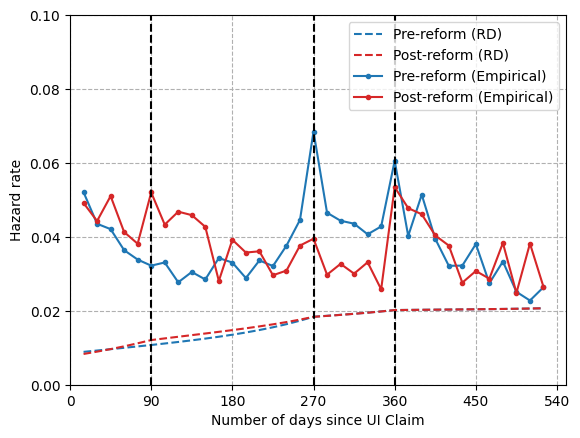

In [ ]:
plt.plot(timevec, pre_st, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_st, label='Post-reform (RD)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

In [ ]:
params_st_full = pd.DataFrame(
    data={"value":params_st},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

In [ ]:
smm_object = model.smm(params_st_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [ ]:
params_est_st = pd.DataFrame(
    data={"value":params_st[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [ ]:
res_st = om.minimize(criterion=smm_object.sse, params=params_est_st, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_st.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_st.criterion}')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:311: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/ho

KeyboardInterrupt: 

# Estimation

This notebook estimates the job-search model in a deliberately fixed order and keeps the estimation output reproducible and easy to export.

**Order**
1. L-BFGS-B: Standard 1 type, Standard 2 type, Standard 3 type, Reference-dependent 1 type.
2. LS-TRF: Standard 1 type, Standard 2 type, Standard 3 type, Reference-dependent 1 type.

For the **standard model**, `eta = 0` and `lambda = 0` are fixed. We estimate `delta`, `gamma`, the relevant search-cost parameters `k`, and the type shares `q`. `N` is fixed.

For the **reference-dependent model**, we use one type and estimate `delta`, `gamma`, `eta`, `k`, and `lambda`, while keeping `N` fixed.

The notebook produces:
- initial-fit and post-estimation hazard plots;
- estimation tables in both DataFrame and LaTeX form;
- goodness of fit (SSE) and elapsed estimation time;
- a type-survival / survivor-composition diagnostic for heterogeneous-type models.

In [ ]:
est_params_st = params_st.copy()
est_params_st[:5] = res_st.params["value"].values


In [ ]:
moments_st_est = model.simulate_moments(est_params_st, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_st))/2)*15 +15 # timevector for plotting graphs 
pre_est_st, post_est_st = split_half(moments_st)

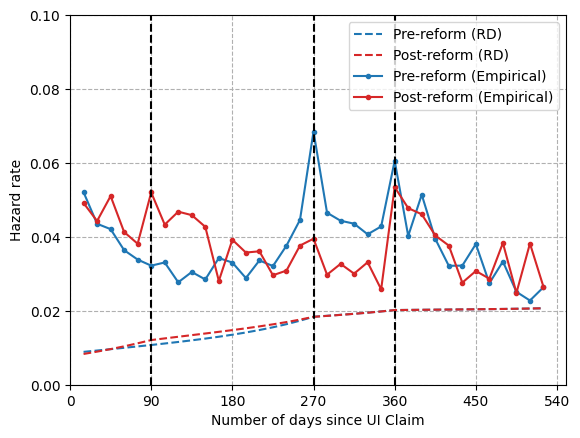

In [ ]:
plt.plot(timevec, pre_est_st, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_est_st, label='Post-reform (RD)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

### 2 type model

In [ ]:
moments_2type = model.simulate_moments(params_twotype, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_2type))/2)*15 +15 # timevector for plotting graphs 

# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)

# Create SSE, distance measure
SSE = model.sse(params_twotype, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 642.5110812146573


In [ ]:
pre_2type, post_2type = split_half(moments_2type)

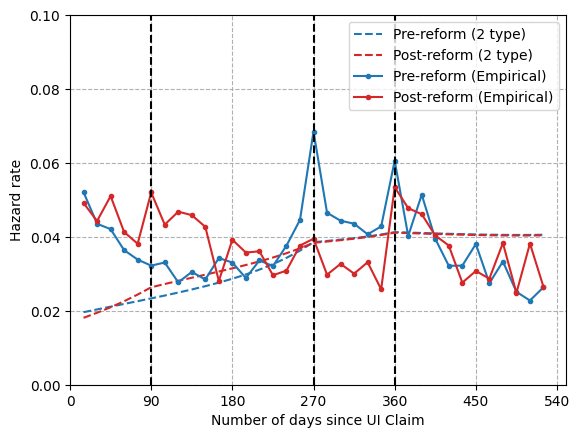

In [ ]:
plt.plot(timevec, pre_2type, label='Pre-reform (2 type)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_2type, label='Post-reform (2 type)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

In [ ]:
params_2type_full = pd.DataFrame(
    data={"value":params_twotype},
    index=["delta", "gamma", "eta", "1", "lmbda", "N", "k2", "q1"]
    )

In [ ]:
smm_object = model.smm(params_2type_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [ ]:
params_est_2type = pd.DataFrame(
    data={"value":np.delete(params_twotype,5),
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01, 0.01, 0],
    "upper_bound" : [0.95, 2, 15, 2000, 15, 2000, 1]},
    index=["delta", "gamma", "eta", "k1", "lmbda", "k2", "q1"],
    )

In [ ]:
res_2type = om.minimize(criterion=smm_object.sse, params=params_est_2type, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_2type.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_2type.criterion}')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:311: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/ho

KeyboardInterrupt: 

### 3 type model

In [ ]:
moments_3type = model.simulate_moments(params_multi, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_3type))/2)*15 +15 # timevector for plotting graphs 

# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)

# Create SSE, distance measure
SSE = model.sse(params_multi, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 356.45125231042795


In [ ]:
pre_3type, post_3type = split_half(moments_3type)

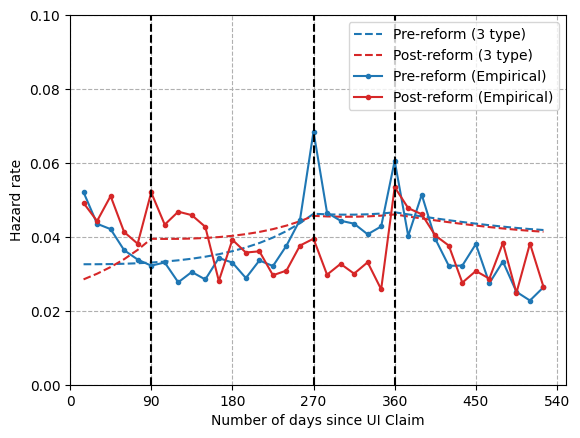

In [ ]:
plt.plot(timevec, pre_3type, label='Pre-reform (3 type)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_3type, label='Post-reform (3 type)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

In [ ]:
params_3type_full = pd.DataFrame(
    data={"value":params_multi},
    index=["delta", "gamma", "eta", "1", "lmbda", "N", "k2", "k3", "q1", "q2"]
    )

In [ ]:
smm_object = model.smm(params_3type_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [ ]:
params_est_3type = pd.DataFrame(
    data={"value":np.delete(params_multi,5),
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01, 0.01, 0.01,0, 0],
    "upper_bound" : [0.95, 2, 15, 2000, 15, 2000, 2000, 1,1]},
    index=["delta", "gamma", "eta", "k1", "lmbda", "k2", "k3", "q1", "q2"],
    )

In [ ]:
res_3type = om.minimize(criterion=smm_object.sse, params=params_est_3type, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_3type.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_3type.criterion}')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


UserFunctionRuntimeError: An error occurred when evaluating a numerical derivative during optimization.

# Estimate Reference Dependent Model

## Simulate Moments, obtain empirical/observed moments, weigting matrix (covariance) and calculate sum of squared errors (distance measure)

In [ ]:
moments_rd = model.simulate_moments(params_rd, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_rd))/2)*15 +15 # timevector for plotting graphs 

# Create SSE, distance measure
SSE = model.sse(params_rd, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 120.74750301158201


In [ ]:
pre_rd, post_rd = split_half(moments_rd)

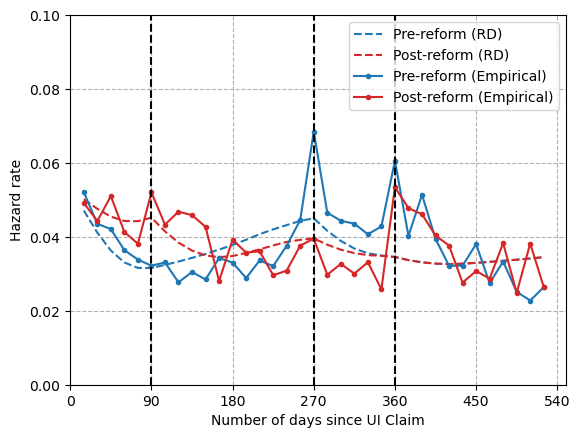

In [ ]:
plt.plot(timevec, pre_rd, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_rd, label='Post-reform (RD)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()

plt.savefig('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Figurer/Prediction HR.pdf', bbox_inches='tight')

plt.show()

### Define full set of parameters in order to estimate model

In [ ]:
params_rd_full = pd.DataFrame(
    data={"value":params_rd},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

params_est_rd = pd.DataFrame(
    data={"value":params_rd[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

## Estimate with Simulated Method of Moments (RD Model & Hand To Mouth)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter

In [ ]:
smm_object = model.smm(params_rd_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [ ]:
params_est_rd = pd.DataFrame(
    data={"value":params_rd[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [ ]:
params_est_std = pd.DataFrame(
    data={"value":params_rd[:5],
    "lower_bound" : [0.01, 0.0, 0.0, 1e-5, 0.01],
    "upper_bound" : [0.95, 0.0, 0.0, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

Print Sum of Squared Errors at initial values

In [ ]:
print(f'SMM SSE for params_rd: {smm_object.sse(params_rd)}')

SMM SSE for params_rd: 707.9312764809315


### Estimate params_rd by minimize the objective function (Algorithms L-BFGS-B and LS-TRF) 

In [ ]:
res_lbfgsb = om.minimize(criterion=smm_object.criterion, params=params_est_rd, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_lbfgsb.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_lbfgsb.criterion}')

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.warn(msg, FutureWarning)


Estimated parameters (L-BFGS-B): [  0.89217042   0.86301388   1.65159136 358.72612023   5.37024574]
SMM SSE for estimated (L-BFGS-B): 140.11151902140597


/opt/anaconda3/lib/python3.12/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


### Plot criterion value at each iteration and number of criterion evaluations before reaching a solution

In [ ]:
fig = om.criterion_plot(res_lbfgsb)
fig

### LS_TRF estimation

In [ ]:
res_ls = om.minimize(criterion=smm_object.criterion, params=params_est_rd, algorithm='scipy_ls_trf', )
print(f'Estimated parameters (LS_TRF): {res_ls.params["value"].values}')
print(f'SMM SSE for estimated (LS_TRF): {res_ls.criterion}')

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning:

To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:333: FutureWarning:

Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html



Estimated parameters (LS_TRF): [9.49970911e-01 1.17590515e+00 1.73359345e+00 1.99955420e+03
 8.63481452e+00]
SMM SSE for estimated (LS_TRF): 120.747503011582


/opt/anaconda3/lib/python3.12/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [ ]:
fig = om.criterion_plot(res_ls)
fig

## Plot estimated parameters for different minimizing algorithms
First we insert the estimated params on our original params array
Then we plot them against observed moments
Then we simulate the model with the estimated moments
Finally p

In [ ]:
#insert 5 estimated params on first 5 columns of original params array
params_lbfgsb = params_rd
params_lbfgsb[:5] = res_lbfgsb.params["value"]

#insert params_rd on first 5 columns of params
params_lstfr = params_rd
params_lstfr[:5] = res_ls.params['value']



In [ ]:
#simulate moments for each set of estimated parameters
# Then split the moments into pre- and post-reform moments for each set of estimated parameters
moments_lbfgsb = model.simulate_moments(params_lbfgsb, institutions_pre, institutions_post, abar, weights, htm)
opt_lbfgsb_pre, opt_lbfgsb_post = split_half(moments_lbfgsb)
moments_lstfr = model.simulate_moments(params_lstfr, institutions_pre, institutions_post, abar, weights, htm)
opt_lstfr_pre, opt_lstfr_post = split_half(moments_lstfr)

emp_pre, emp_post = split_half(target)


### Plot for the L-BGSB-B estimator

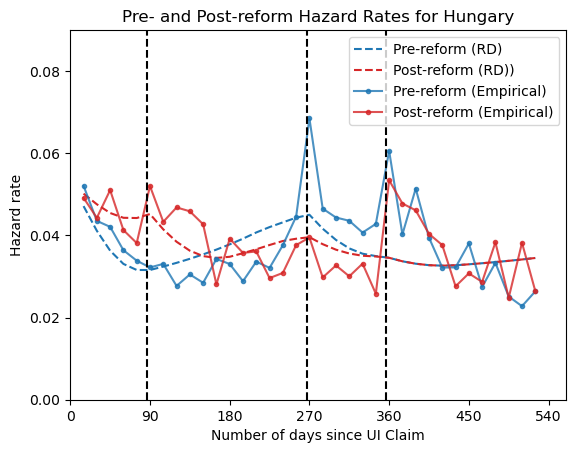

In [ ]:
plt.plot(timevec, opt_lbfgsb_pre, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, opt_lbfgsb_post, label='Post-reform (RD))', linestyle='dashed', color='tab:red')
timevec2 = timevec + 15
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue', alpha=0.8)
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red', alpha=0.8)

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.xticks(np.arange(0, 541, 90))
plt.ylabel('Hazard rate')
plt.ylim(0, 0.09) # set x-axis limits to first and last element in timevec
plt.yticks(np.arange(0, 0.09, 0.02))
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[T1*15-3, T2*15-3, T3*15-3], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.show()

#### Goodness of Fit (SSE), L-BGSB-B estimator

In [ ]:
res_ls.params
res_lbfgsb.params

,value,lower_bound,upper_bound
delta,0.892170,0.01000,0.95
gamma,0.863014,0.01000,2.00
eta,1.651591,0.01000,15.00
k,358.726120,0.00001,2000.00
lmbda,5.370246,0.01000,15.00


### Plot for the L-STFR estimator

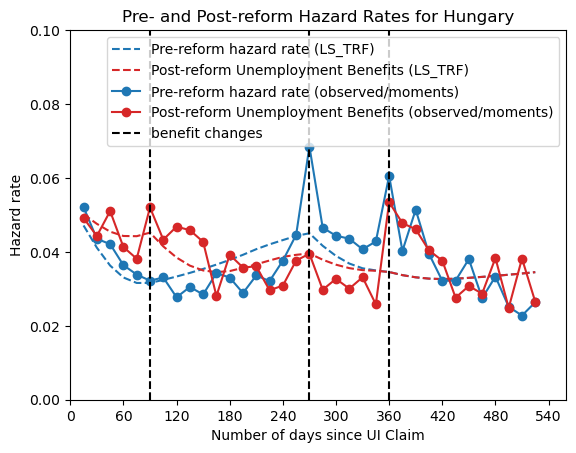

In [ ]:
plt.plot(timevec, opt_lstfr_pre, label='Pre-reform hazard rate (LS_TRF)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, opt_lstfr_post, label='Post-reform Unemployment Benefits (LS_TRF)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

## Estimate with Simulated Method of Moments (RD Model & Heterogenous Assets)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter

## Estimate with Simulated Method of Moments (Standard Model & Hand To Mouth)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter

## Estimate with Simulated Method of Moments (Standard Model & Heterogenous Assets)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter